In [ ]:
import plotly.express as px
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("top_rated_tv.csv")
df.info()
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2408 entries, 0 to 2407
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_air_date  2408 non-null   object 
 1   name            2408 non-null   object 
 2   overview        2386 non-null   object 
 3   popularity      2408 non-null   float64
 4   vote_average    2408 non-null   float64
 5   vote_count      2408 non-null   int64  
 6   adult           2408 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(3)
memory usage: 115.4+ KB
     first_air_date                           name  \
0        2008-01-20                   Breaking Bad   
1        2023-09-29  Frieren: Beyond Journey's End   
2        2015-11-06                     Reply 1988   
3        2005-02-21     Avatar: The Last Airbender   
4        2021-11-06                         Arcane   
...             ...                            ...   
2403     2025-06-24                   

In [2]:
df["adult"]=df["adult"].replace({True:1,False:0})
print(df["adult"])

0       0
1       0
2       0
3       0
4       0
       ..
2403    0
2404    0
2405    0
2406    0
2407    0
Name: adult, Length: 2408, dtype: int64


/var/folders/rj/yzdtrlc11gz0vt7njkp70yf80000gn/T/ipykernel_44414/1581424062.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["adult"]=df["adult"].replace({True:1,False:0})


In [3]:
df.dropna(inplace=True)
df=df.reset_index(drop=True)

print(df)


     first_air_date                           name  \
0        2008-01-20                   Breaking Bad   
1        2023-09-29  Frieren: Beyond Journey's End   
2        2015-11-06                     Reply 1988   
3        2005-02-21     Avatar: The Last Airbender   
4        2021-11-06                         Arcane   
...             ...                            ...   
2381     2025-06-24                      Ironheart   
2382     2021-09-03              The D'Amelio Show   
2383     2000-07-05                    Big Brother   
2384     1985-02-19                     EastEnders   
2385     2023-01-12                          Velma   

                                               overview  popularity  \
0     Walter White, a New Mexico chemistry teacher, ...    122.1631   
1     Decades after her party defeated the Demon Kin...     86.7104   
2     Take a nostalgic trip back to the late 1980s t...     15.7551   
3     In a war-torn world of elemental magic, a youn...     40.7230

[Text(0, 3, '17539'), Text(0, 3, '815'), Text(0, 3, '311')]

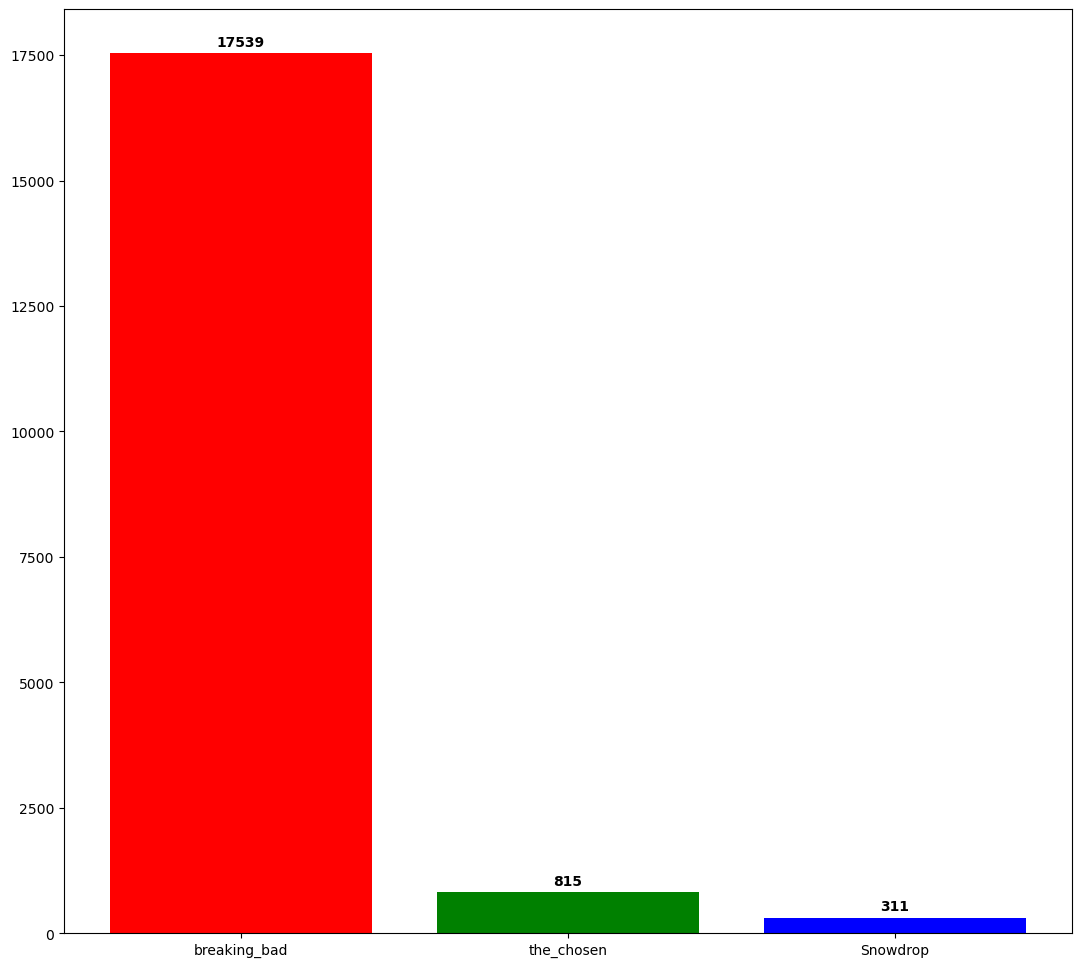

In [4]:
breaking_bad=df[df["name"].str.strip()=="Breaking Bad"]
#print(breaking_bad)
Snowdrop=df[df["name"].str.strip()=="Snowdrop"]
#print(Snowdrop)
the_chosen=df[df['name']=="The Chosen"]
# print(the_chosen)
# print(df.columns)

df1=pd.DataFrame(data={"breaking_bad":breaking_bad['vote_count'].values,"the_chosen":the_chosen['vote_count'].values,"Snowdrop":Snowdrop['vote_count'].values})
plt.figure(figsize=(13,12))

bars=plt.bar(df1.columns,df1.iloc[0],color=['red','green','blue'])
plt.bar_label(bars,padding=3,fontweight='bold')

In [1]:
plt.figure(figsize=(10,12))

plt.pie(df1.iloc[0],labels=df1.columns,autopct="%1.1f%%",labeldistance=0.4,pctdistance=0.7)

NameError: name 'plt' is not defined

(array([2., 0., 1.]),
 array([  311.        ,  6053.66666667, 11796.33333333, 17539.        ]),
 <BarContainer object of 3 artists>)

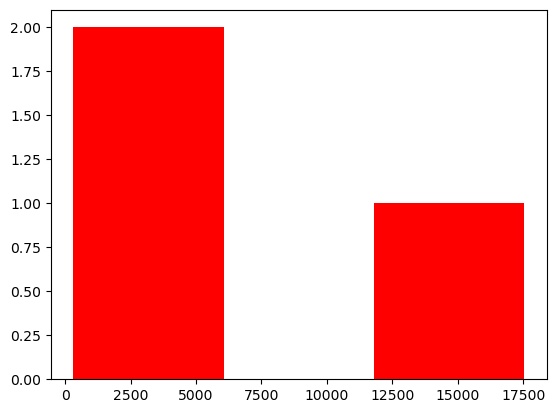

In [6]:
plt.hist(df1.iloc[0],bins=3,color='red')

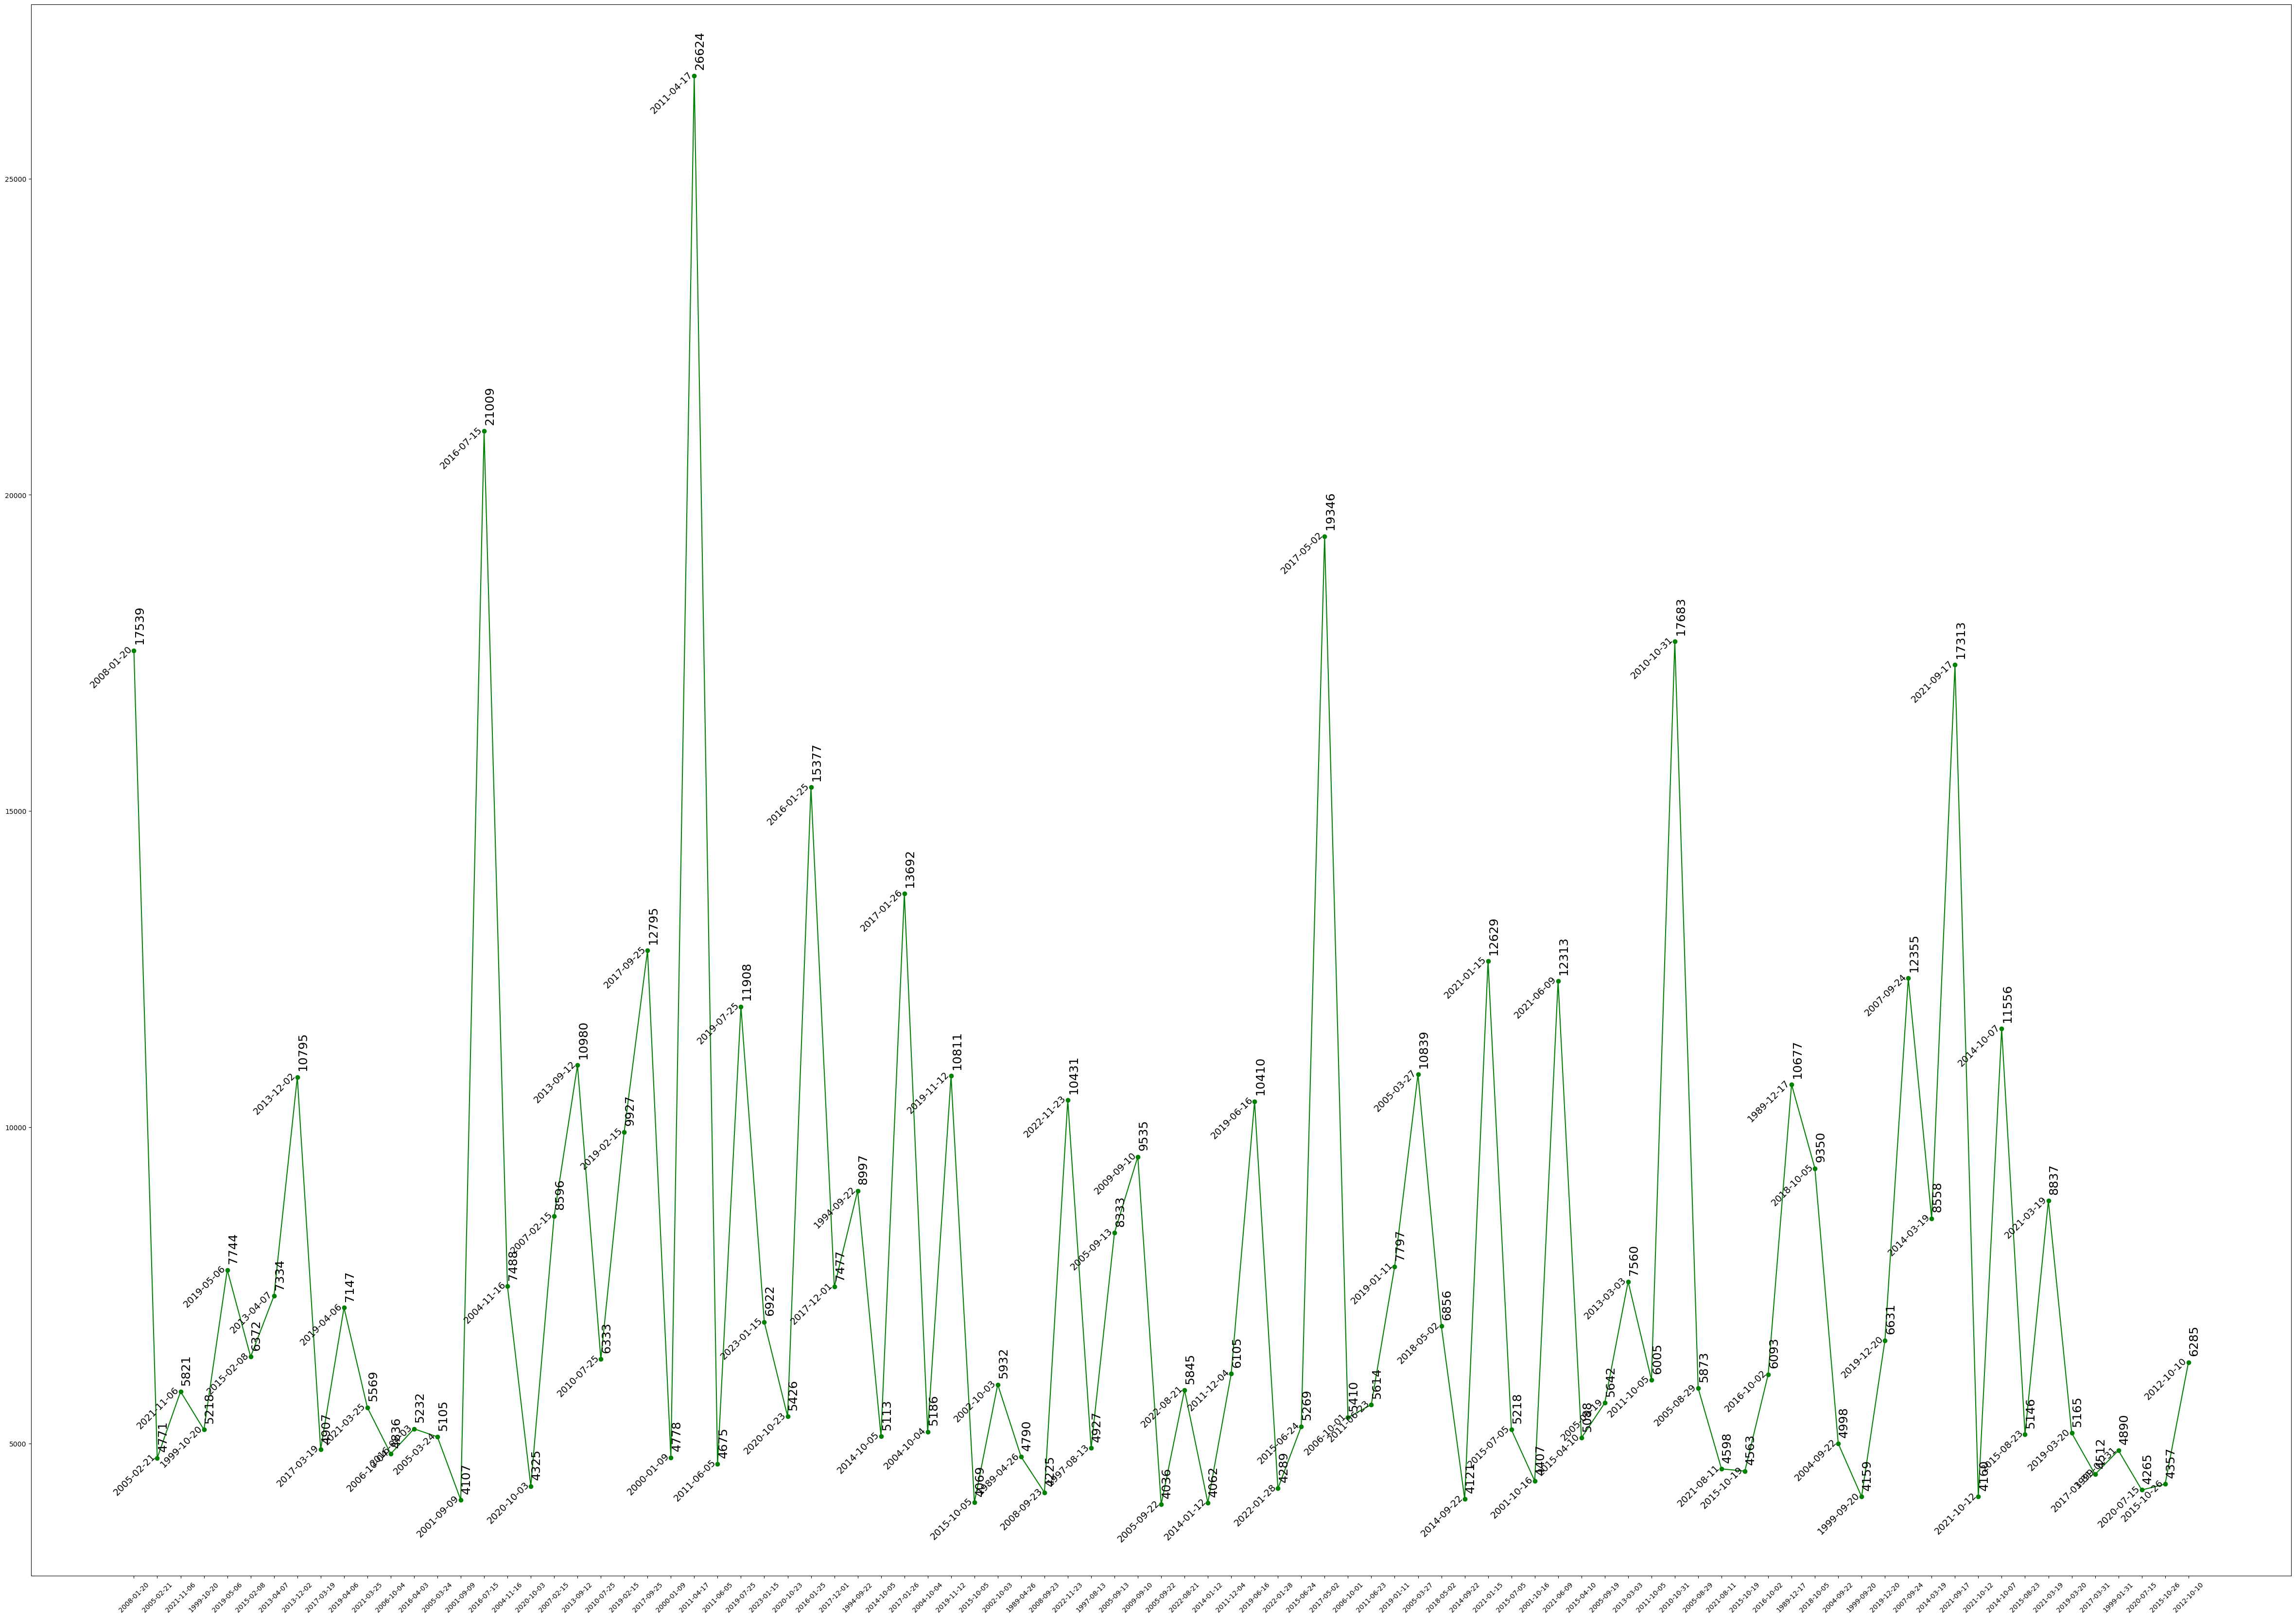

In [7]:
df=df[df['vote_count']>4000]
plt.figure(figsize=(60,42))
plt.plot(df['first_air_date'],df['vote_count'],color='green',marker='o')
plt.xticks(rotation=45)
for x,y in zip(df['first_air_date'],df['vote_count']):
    plt.text(x,y+100,(str(y)),ha='left',va='bottom',fontsize=18,rotation=90)
   
for x,y in zip(df['first_air_date'],df['vote_count']):
      plt.text(x,y+100,str(x),ha='right',va='top',fontsize=14,rotation=45)

<Axes: >

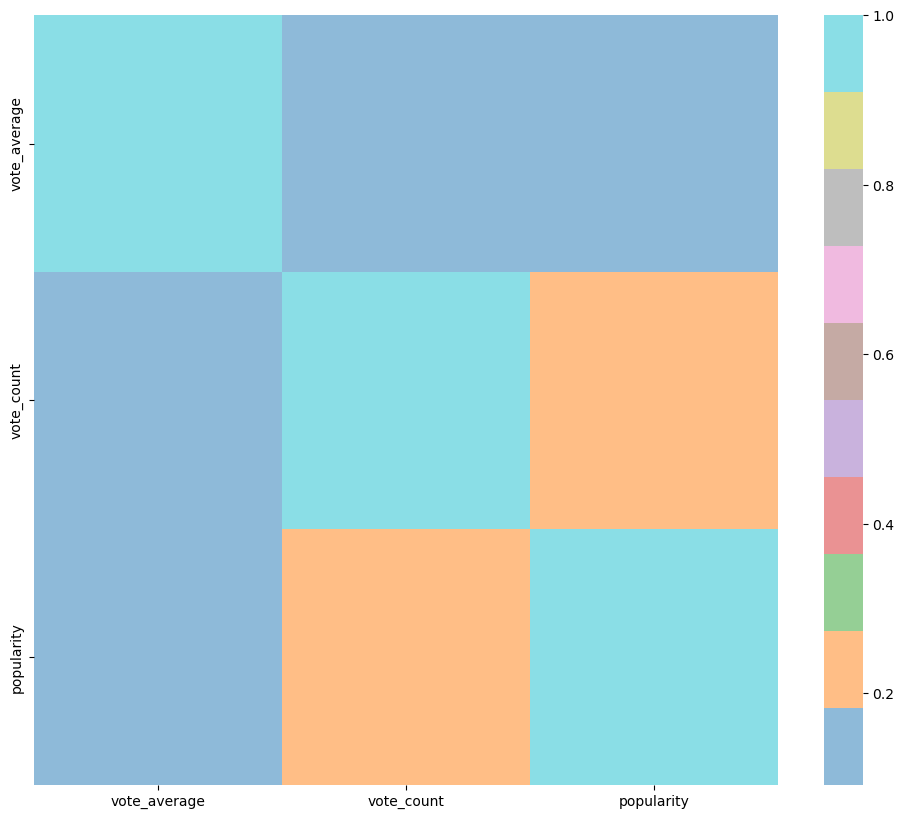

In [8]:
import seaborn as sns

plt.figure(figsize=(12,10))


sns.heatmap((df[['vote_average','vote_count','popularity']]).corr(),fmt='.2f',cmap='tab10',alpha=0.5)

Text(0.5, 0, 'Dates')

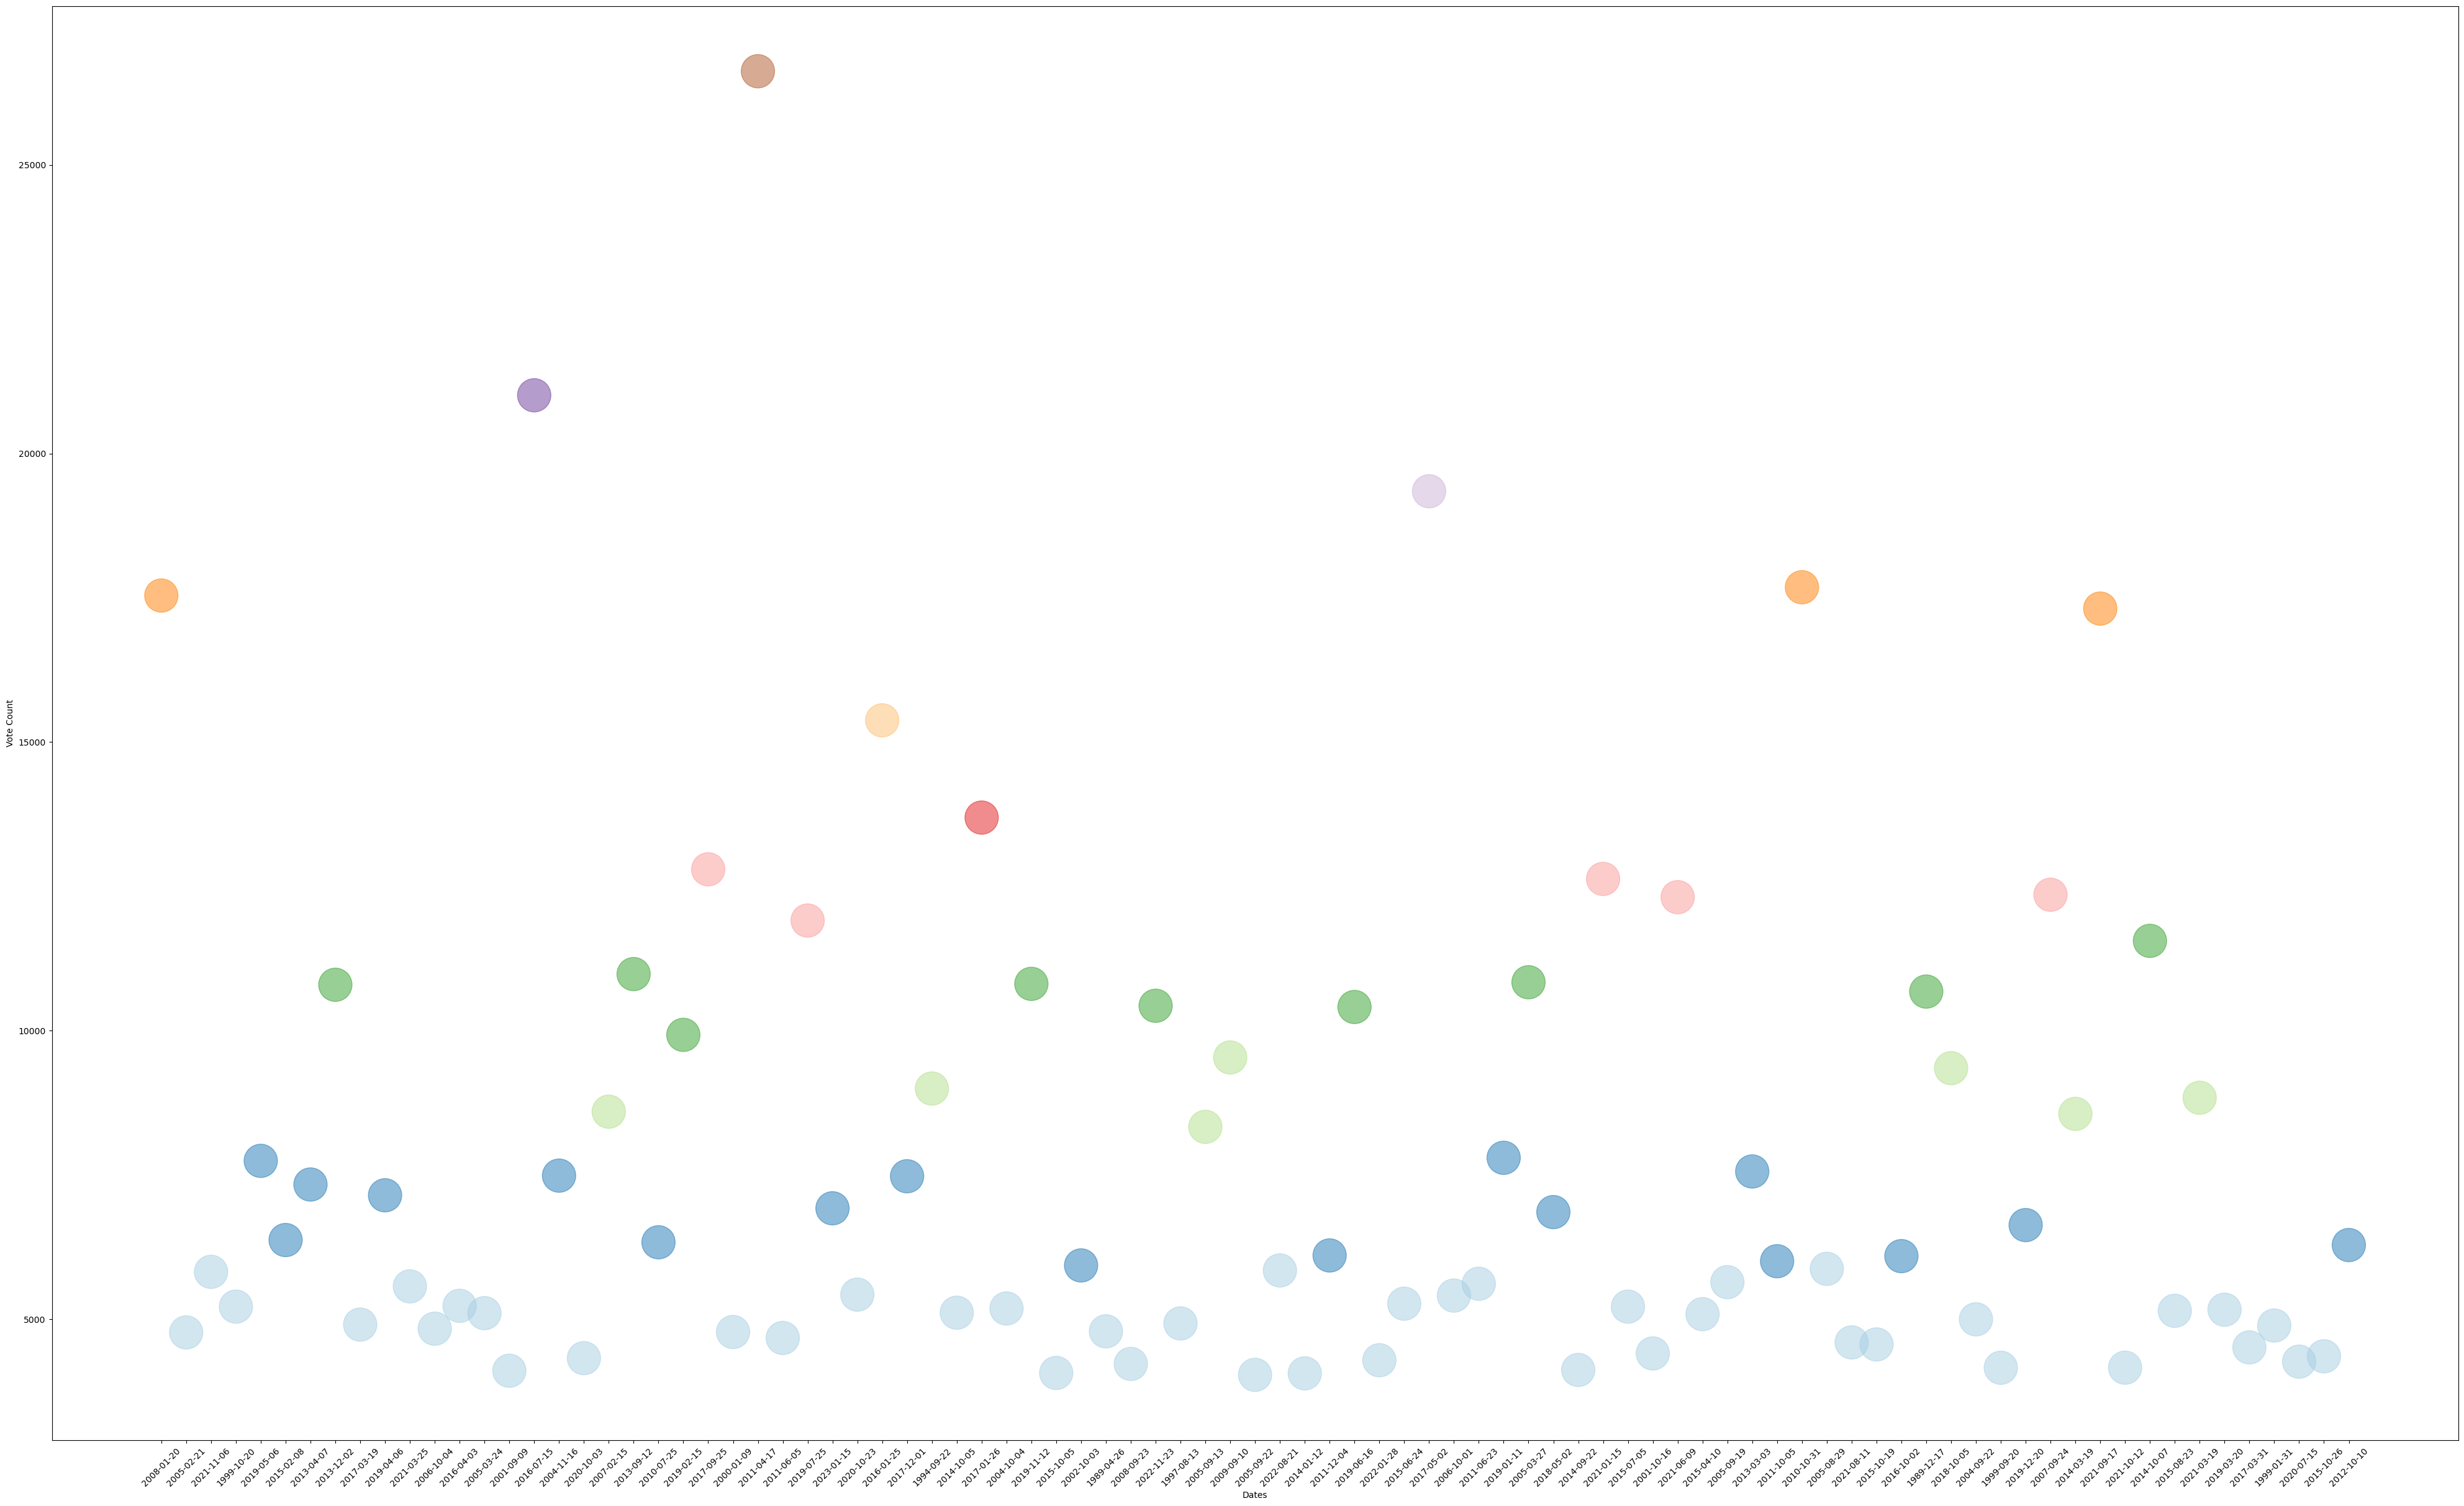

In [9]:
plt.figure(figsize=(50,30))
plt.scatter(df['first_air_date'],df['vote_count'],alpha=0.5,s=1500,cmap='Paired',c=df['vote_count'])
plt.xticks(rotation=45)
plt.ylabel('Vote Count')
plt.xlabel('Dates')

vote_average    1.000000
popularity      0.091554
vote_count      0.135119
movie_age       0.070284
Name: vote_average, dtype: float64
Mean squared error:0.11328321290995665
R2 score:-0.0839575215717474
-17.825821164853885
first_air_date        0
name                  0
overview              0
popularity            0
vote_average          0
vote_count            0
adult                 0
movie_releasedDate    0
movie_age             0
vote_density          0
predicted_rating      0
dtype: int64
Top 10 popular movies are:                          name  predicted_rating  movie_age
1                   Death Note          8.419088         20
2              Attack on Titan          8.397899         13
3                     Sherlock          8.371138         16
4              Stranger Things          8.357755         10
5   Avatar: The Last Airbender          8.354814         21
6               Peaky Blinders          8.352836         13
7                    Chernobyl          8.344888      

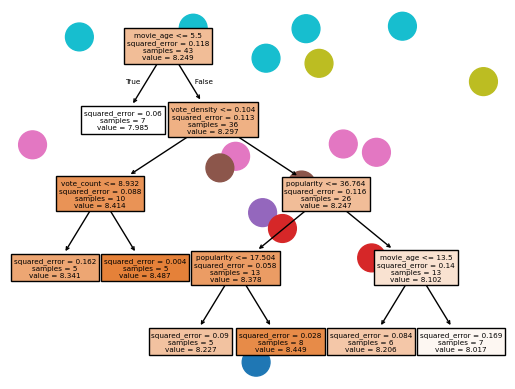

In [10]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeRegressor,plot_tree,export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

df['vote_count']=np.log1p(df['vote_count'])
df['movie_releasedDate']=pd.to_datetime(df['first_air_date'])
df['movie_age']=pd.Timestamp.now().year-df['movie_releasedDate'].dt.year
df['adult']=df['adult'].replace({True:1,False:0})
df['adult']=df['adult'].astype(int)
df['vote_density']=df['vote_count']/(df['popularity']+1)
# df['popularity']=np.log1p(df['popularity'])
y=df['vote_average']
X=df[['popularity','vote_count','adult','movie_age','adult','vote_density']]
print(df[['vote_average', 'popularity', 'vote_count', 'movie_age']].corr()['vote_average'])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestRegressor(max_depth=4,n_estimators=150,random_state=1,min_samples_leaf=5,max_features='sqrt')

model.fit(X_train,y_train)
y_pred=model.predict(X_test)
tree=model.estimators_[0]
plot_tree(tree,feature_names=X.columns,filled=True)
plt.scatter(y_test,y_pred,s=400,c=y_pred,cmap='tab10')
# print(y_pred)
print(f"Mean squared error:{mean_squared_error(y_test,y_pred)}")
print(f"R2 score:{r2_score(y_test,y_pred)}")


df['predicted_rating']=model.predict(X)

importance=model.feature_importances_
fi_df=pd.DataFrame(data={'Features':X.columns,'Importance':importance})
scores=cross_val_score(model,X,y,cv=5,scoring='r2')
print(scores.mean())
# print(fi_df)
print(df.isnull().sum())
ranked=df.sort_values(by='predicted_rating',ascending=False).reset_index(drop=True)
ranked.index=ranked.index+1
print(f"Top 10 popular movies are:{ranked[['name','predicted_rating','movie_age']].head(10)}")